<a href="https://colab.research.google.com/github/cuboidalstudios/ML_REF_DEF/blob/main/Machine_Learning_REFDEF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CM2604: Machine Learning REF/DEF**


---
***Bank Marketing - UCI Machine Learning Repository***


importing modules for reading data and EDA

In [ ]:
from google.colab import drive

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


replacing csv limiter to comma instead of ;

In [ ]:
f = open("/content/drive/MyDrive/bank-additional-full.csv")
data = f.read()

for i in data:
  if i == ';':
    data = data.replace(i, ',')

f = open("/content/drive/MyDrive/bank-additional-full.csv", "w")
f.write(data)
f.close()

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/bank-additional-full.csv")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
null_sum = df.isna().sum()

duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}\nNumber of null rows:\n{null_sum}")

Number of duplicate rows: 12
Number of null rows:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

## Data Cleaning & Feature Engineering

In [ ]:
df = df.drop_duplicates()
df.shape

(41176, 21)

the dataset doesnt use NaN for missing data, instead a few columns use the string 'unknown'.
checking how much of each column is affected before deciding what to do with it

In [ ]:
cat_cols = df.select_dtypes(include='object').columns.drop('y')

for col in cat_cols:
    n_unknown = (df[col] == 'unknown').sum()
    if n_unknown > 0:
        print(f"{col}: {n_unknown} unknown values ({n_unknown/len(df)*100:.1f}%)")

job: 330 unknown values (0.8%)
marital: 80 unknown values (0.2%)
education: 1730 unknown values (4.2%)
default: 8596 unknown values (20.9%)
housing: 990 unknown values (2.4%)
loan: 990 unknown values (2.4%)


default has a fairly large chunk of unknowns (20.9%), the rest are smaller. dropping these rows would lose
a lot of data and the missingness probably isnt random anyway (people who dont say if they defaulted are
maybe not a random sample), so instead of dropping or imputing we just leave 'unknown' in as its own
category, both models can handle that fine once encoded

In [ ]:
# pdays uses 999 to mean 'client was never contacted before', if we leave that as-is a model
# would treat 999 as some huge numeric distance instead of a flag, so we pull it out into its own column
df['was_previously_contacted'] = (df['pdays'] != 999).astype(int)
df[['pdays', 'was_previously_contacted']].head()

,pdays,was_previously_contacted
0,999,0
1,999,0
2,999,0
3,999,0
4,999,0


In [ ]:
# encode target as 0/1 to make plotting/correlation easier later on
df['y_encoded'] = df['y'].map({'yes': 1, 'no': 0})
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,was_previously_contacted,y_encoded
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,0


## Exploratory Data Analysis

### Five Number Summary

In [ ]:
num_cols = ['age', 'duration', 'campaign', 'previous', 'emp.var.rate',
            'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
df[num_cols].describe().loc[['min', '25%', '50%', '75%', 'max']]

,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
min,17.0,0.0,1.0,0.0,-3.4,92.201,-50.8,0.634,4963.6
25%,32.0,102.0,1.0,0.0,-1.8,93.075,-42.7,1.344,5099.1
50%,38.0,180.0,2.0,0.0,1.1,93.749,-41.8,4.857,5191.0
75%,47.0,319.0,3.0,0.0,1.4,93.994,-36.4,4.961,5228.1
max,98.0,4918.0,56.0,7.0,1.4,94.767,-26.9,5.045,5228.1


### Target distribution

In [ ]:
df['y'].value_counts()

,count
y,
no,36537
yes,4639


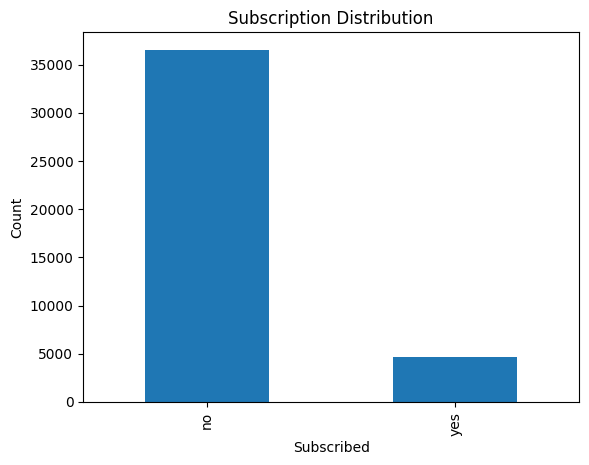

In [ ]:
df['y'].value_counts().plot(kind='bar')
plt.title('Subscription Distribution')
plt.xlabel('Subscribed')
plt.ylabel('Count')
plt.show()

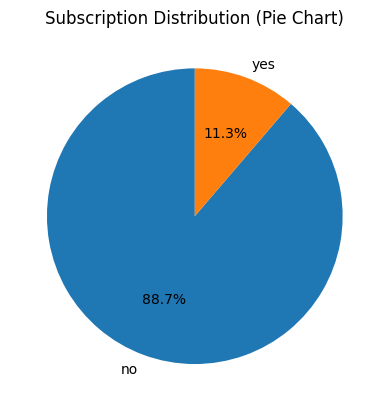

In [ ]:
df['y'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Subscription Distribution (Pie Chart)')
plt.ylabel('')
plt.show()

most clients did not subscribe, the classes are pretty imbalanced here so accuracy alone wont tell us much
later on, a model that just predicts 'no' every time would still score well over 80% while being useless